In [18]:
import numpy as np
import matplotlib.pyplot as plt

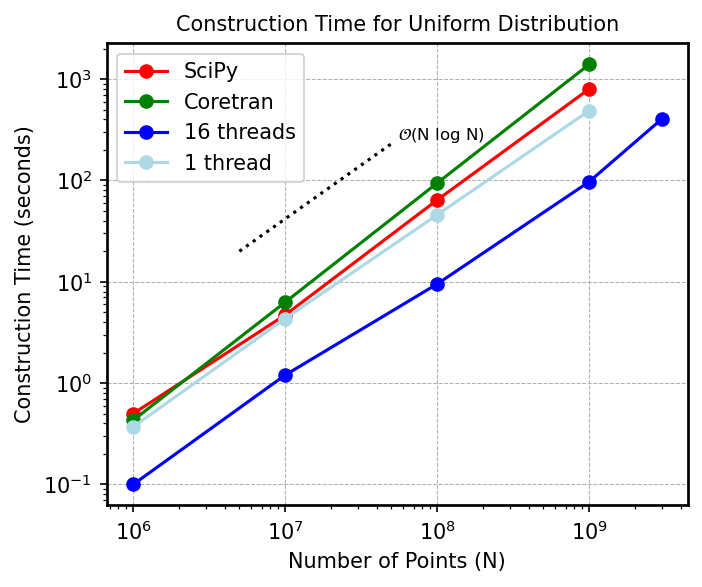

In [ ]:
# UNIFORM DISTRIBUTION

#CONSTRUCTION TIME
# Data points (Number of points N and Construction time in seconds)
N_gcc_parallel = np.array([1e6,1e7,1e8,1e9,3e9])
N_gcc_serial = np.array([1e6,1e7,1e8,1e9])
time_scipy_serial = np.array([0.5, 4.7, 64, 797])
time_gcc_serial = np.array([0.37, 4.33, 45.7, 487., ])  
time_gcc_parallel = np.array([0.1, 1.2, 9.5, 96.9, 402.])  
time_coretran_serial = np.array([0.43, 6.28, 94, 1393])

# Reference O(N log N) scaling
N_ref = np.array([5e6,5e7])
t0 = 20.
N0 = 5e6
scaling_ref = (t0 / (N0 * np.log(N0))) * N_ref * np.log(N_ref)

# Plot settings
plt.figure(figsize=(5,4), dpi = 150)
plt.title('Uniform Distribution', fontsize=10)
plt.loglog(N_gcc_serial, time_scipy_serial, 'o-', label='SciPy', color='red')
plt.loglog(N_gcc_serial, time_coretran_serial, 'o-', label='Coretran', color='green')
plt.loglog(N_gcc_parallel, time_gcc_parallel, 'o-', label='16 threads', color='blue')
plt.loglog(N_gcc_serial, time_gcc_serial, 'o-', label='1 thread', color='lightblue')
plt.loglog(N_ref, scaling_ref, color='black', linestyle='dotted')
plt.text(1.1*N_ref[-1], 1.1*scaling_ref[-1], '$\mathcal{O}$(N log N)', fontsize=8, color='black')

# Labels and title
plt.xlabel('Number of Points (N)')
plt.ylabel('Construction Time (seconds)')
plt.legend()
#thicker axis lines
plt.gca().spines['top'].set_linewidth(1.3)
plt.gca().spines['right'].set_linewidth(1.3)
plt.gca().spines['bottom'].set_linewidth(1.3)
plt.gca().spines['left'].set_linewidth(1.3)

plt.grid(True, which="major", linestyle='--', linewidth=0.5)
plt.savefig('construction_uniform.png')

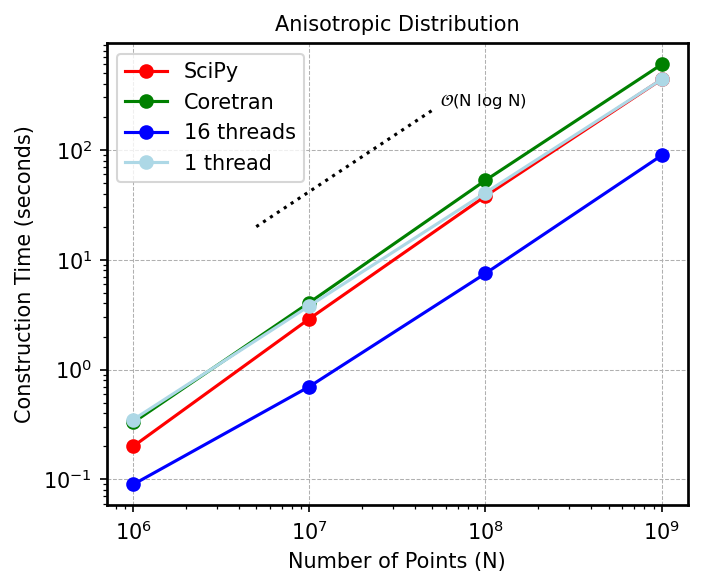

In [23]:
# ANISOTROPIC DISTRIBUTION

#CONSTRUCTION TIME
# Data points (Number of points N and Construction time in seconds)
N_gcc_parallel = np.array([1e6,1e7,1e8,1e9])
N_gcc_serial = np.array([1e6,1e7,1e8,1e9])

time_scipy_serial = np.array([   0.20, 2.9,  38.,   438.])
time_gcc_serial = np.array([     0.35, 3.8,  40.7, 438., ])  
time_gcc_parallel = np.array([   0.09, 0.7,  7.5,  89.,])  
time_coretran_serial = np.array([0.33, 4.07, 52.8, 599.])

# Reference O(N log N) scaling
N_ref = np.array([5e6,5e7])
t0 = 20.
N0 = 5e6
scaling_ref = (t0 / (N0 * np.log(N0))) * N_ref * np.log(N_ref)

# Plot settings
plt.figure(figsize=(5,4), dpi = 150)
plt.title('Anisotropic Distribution', fontsize=10)
plt.loglog(N_gcc_serial, time_scipy_serial, 'o-', label='SciPy', color='red')
plt.loglog(N_gcc_serial, time_coretran_serial, 'o-', label='Coretran', color='green')
plt.loglog(N_gcc_parallel, time_gcc_parallel, 'o-', label='16 threads', color='blue')
plt.loglog(N_gcc_serial, time_gcc_serial, 'o-', label='1 thread', color='lightblue')
plt.loglog(N_ref, scaling_ref, color='black', linestyle='dotted')
plt.text(1.1*N_ref[-1], 1.1*scaling_ref[-1], '$\mathcal{O}$(N log N)', fontsize=8, color='black')

# Labels and title
plt.xlabel('Number of Points (N)')
plt.ylabel('Construction Time (seconds)')
plt.legend()
#thicker axis lines
plt.gca().spines['top'].set_linewidth(1.3)
plt.gca().spines['right'].set_linewidth(1.3)
plt.gca().spines['bottom'].set_linewidth(1.3)
plt.gca().spines['left'].set_linewidth(1.3)

plt.grid(True, which="major", linestyle='--', linewidth=0.5)
plt.savefig('construction_anisotropic.png')

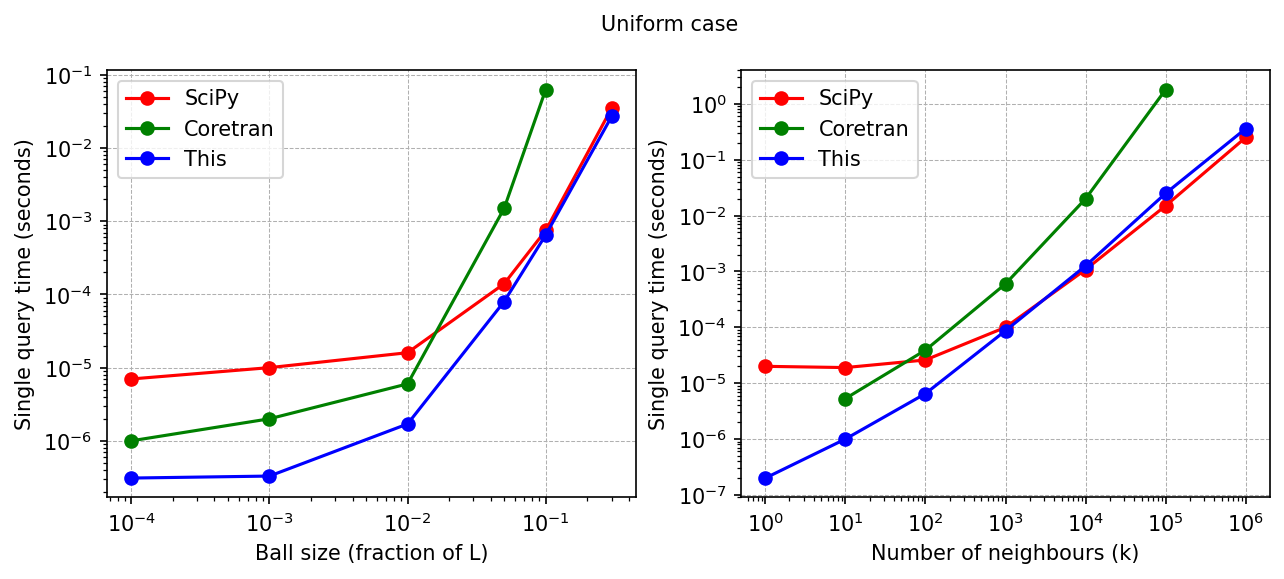

In [11]:
#UNIFORM CASE!!!!!!!!!!!!!!!!!!!

# Plot QUERY TIME
# Not plot here but query time is as fast as Coretran's implementation
k = [1,10,100,1000,10000,100000, 1e6]
ball = [0.01,0.1,1,5,10,30]

t_k_gcc =      [2e-7,   1e-6,   6.5e-6, 8.7e-5, 1.26e-3, 2.5e-2, 0.36]
t_k_coretran = [np.nan, 5.3e-6, 3.9e-5, 6e-4,   2e-2,    1.8,    np.nan]
t_k_scipy =    [2.e-5,  1.9e-5, 2.6e-5, 1.e-4,  1.08e-3, 1.5e-2, 0.25]

t_ball_gcc =      [3.1e-7, 3.3e-7, 1.7e-6, 8.e-5,  6.5e-4, 2.7e-2]
t_ball_coretran = [1e-6,   2e-6,   6e-6,   1.5e-3, 6.3e-2, np.nan]
t_ball_scipy =    [7e-6,   1e-5,   1.6e-5, 1.4e-4, 7.5e-4, 3.5e-2]


# Plot settings ( vertical)
plt.figure(figsize=(10,3.7), dpi = 150,)
plt.suptitle('Uniform case', fontsize=10)
plt.subplot(1,2,1)
plt.loglog(np.array(ball[:len(t_ball_scipy)])/100., t_ball_scipy, 'o-', label='SciPy', color='red')
plt.loglog(np.array(ball[:len(t_ball_coretran)])/100., t_ball_coretran, 'o-', label='Coretran', color='green')
plt.loglog(np.array(ball)/100., t_ball_gcc, 'o-', label='This', color='blue')
plt.xlabel('Ball size (fraction of L)')
plt.ylabel('Single query time (seconds)')
plt.legend()
plt.grid(True, which="major", linestyle='--', linewidth=0.5)

plt.subplot(1,2,2)
plt.loglog(k[:len(t_k_scipy)], t_k_scipy, 'o-', label='SciPy', color='red')
plt.loglog(k[:len(t_k_coretran)], t_k_coretran, 'o-', label='Coretran', color='green')
plt.loglog(k, t_k_gcc, 'o-', label='This', color='blue')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('Single query time (seconds)')
plt.legend()
plt.grid(True, which="major", linestyle='--', linewidth=0.5)


plt.savefig('query_uniform.png')



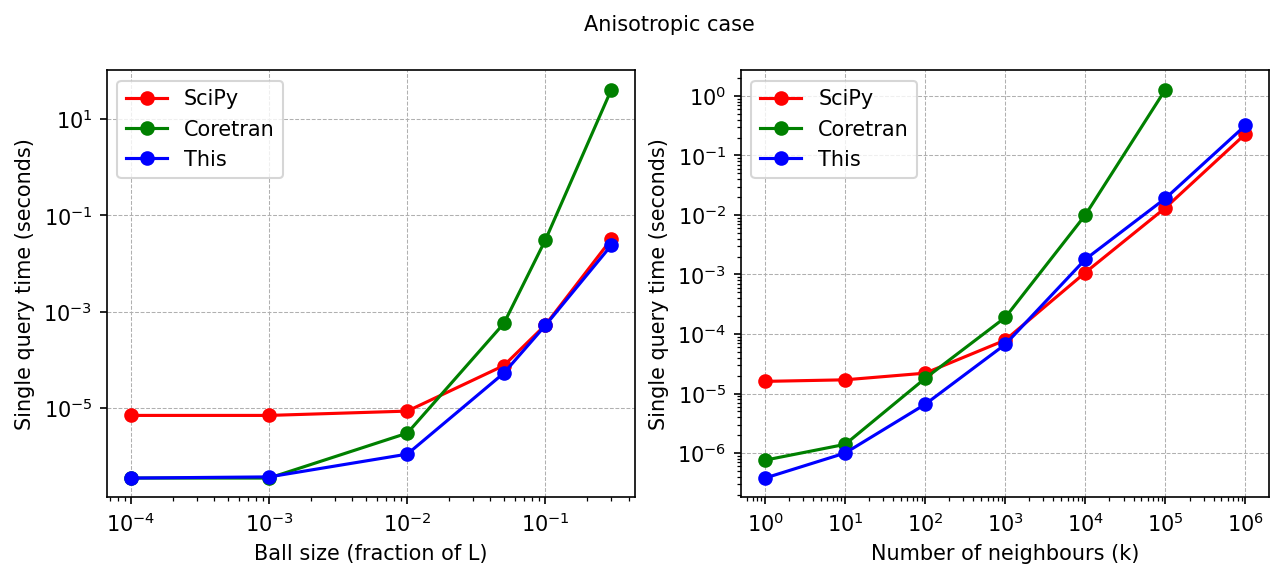

In [25]:
#ANISOTROPIC CASE!!!!!!!!!!!!!!!!!!!

# Plot QUERY TIME
# Not plot here but query time is as fast as Coretran's implementation
k = [1,10,100,1000,10000,100000,1e6]
ball = [0.01,0.1,1,5,10,30]
t_k_gcc =      [3.8e-7,  1e-6,   6.6e-6, 6.7e-5, 1.8e-3, 1.9e-2, 0.32]
t_k_coretran = [7.6e-7,  1.4e-6, 1.8e-5, 1.9e-4, 1e-2,   1.28  , np.nan]
t_k_scipy =    [1.6e-5,  1.7e-5, 2.2e-5, 7.9e-5,  1.08e-3,1.32e-2, 0.23]

t_ball_gcc =      [3.5e-7, 3.7e-7, 1.1e-6, 5.3e-5, 5.2e-4, 2.4e-2]
t_ball_coretran = [3.5e-7, 3.5e-7, 3e-6,   5.7e-4, 3.1e-2, 41.]
t_ball_scipy =    [7e-6,   7e-6,   8.6e-6, 7.6e-5, 5.3e-4, 3.2e-2]

# Plot settings ( vertical)
plt.figure(figsize=(10,3.7), dpi = 150,)
plt.suptitle('Anisotropic case', fontsize=10)
plt.subplot(1,2,1)
plt.loglog(np.array(ball[:len(t_ball_scipy)])/100., t_ball_scipy, 'o-', label='SciPy', color='red')
plt.loglog(np.array(ball[:len(t_ball_coretran)])/100., t_ball_coretran, 'o-', label='Coretran', color='green')
plt.loglog(np.array(ball)/100., t_ball_gcc, 'o-', label='This', color='blue')
plt.xlabel('Ball size (fraction of L)')
plt.ylabel('Single query time (seconds)')
plt.legend()
plt.grid(True, which="major", linestyle='--', linewidth=0.5)

plt.subplot(1,2,2)
plt.loglog(k[:len(t_k_scipy)], t_k_scipy, 'o-', label='SciPy', color='red')
plt.loglog(k[:len(t_k_coretran)], t_k_coretran, 'o-', label='Coretran', color='green')
plt.loglog(k, t_k_gcc, 'o-', label='This', color='blue')
plt.xlabel('Number of neighbours (k)')
plt.ylabel('Single query time (seconds)')
plt.legend()
plt.grid(True, which="major", linestyle='--', linewidth=0.5)


plt.savefig('query_anisotropic.png')